All node IDs in range were used at least once.


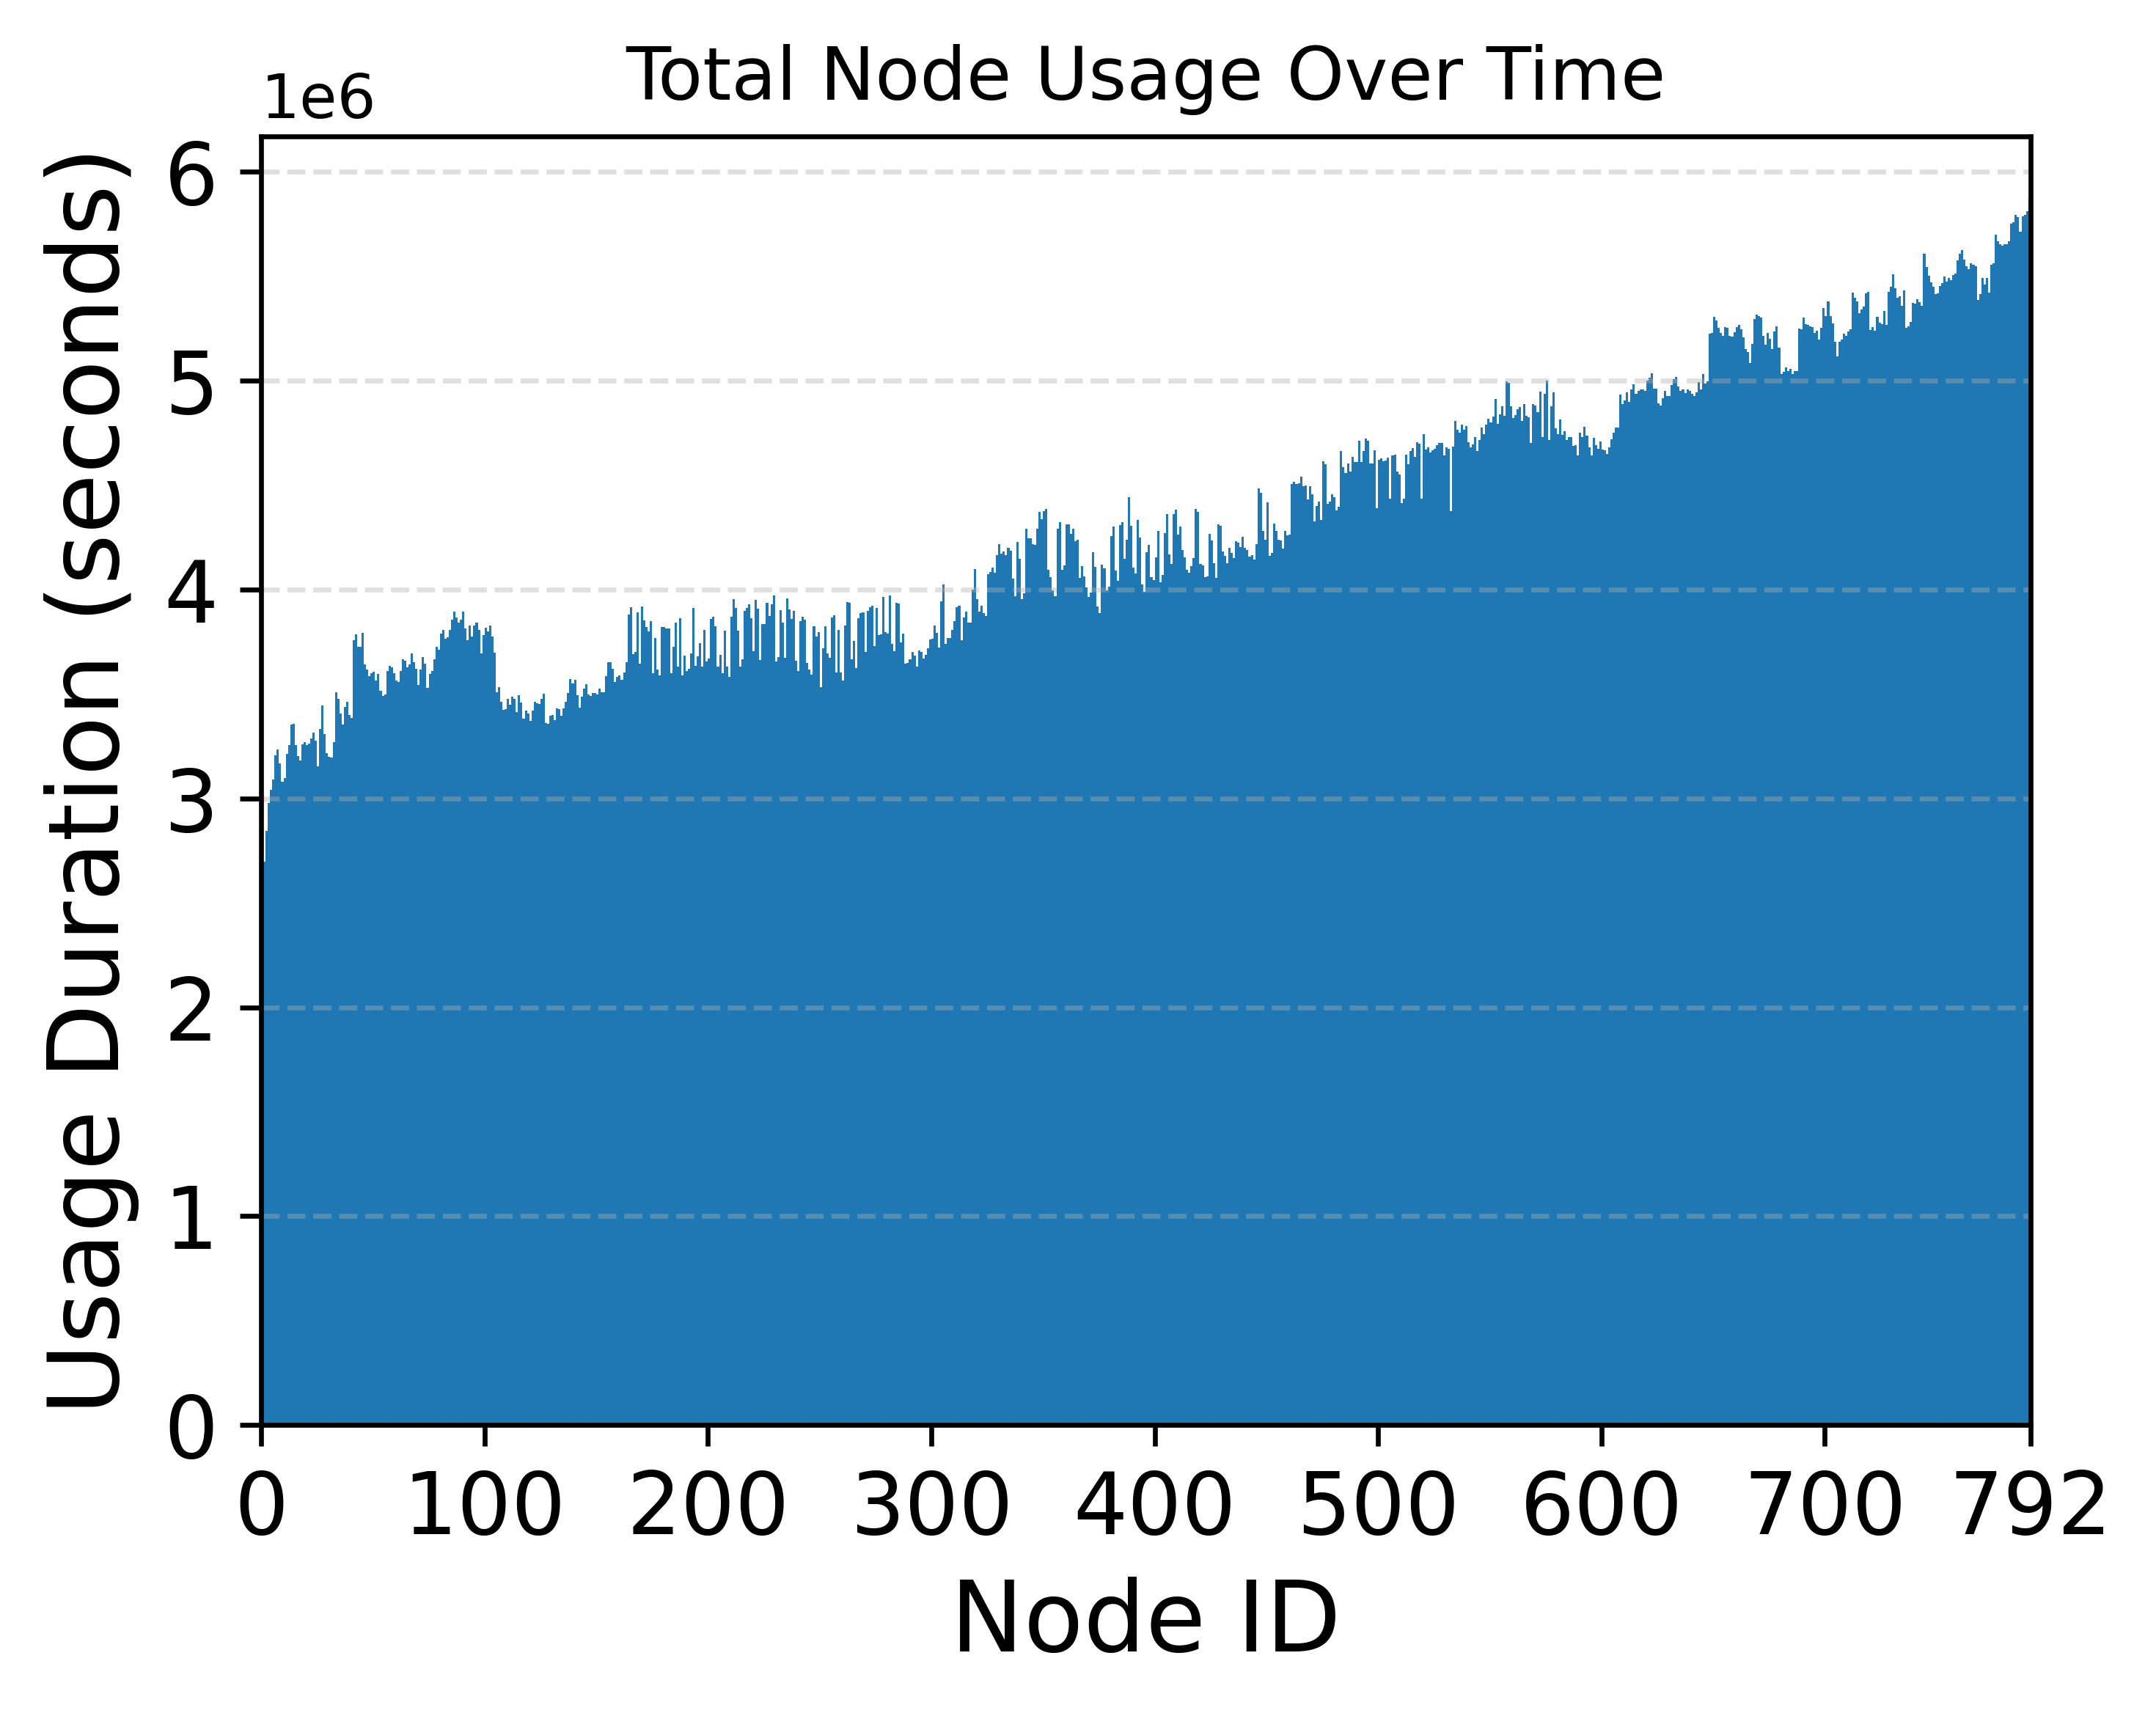

In [10]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

def _parse_nodes(nodelist):
    if pd.isna(nodelist):
        return []
    s = str(nodelist).strip()
    if s.startswith('['):
        try:
            return [int(x) for x in ast.literal_eval(s)]
        except Exception:
            pass
    if ',' in s:
        return [int(x.strip()) for x in s.split(',') if x.strip()]
    return [int(s)]

def plot_node_usage_dense(csv_path,
                          order='id',        
                          fill_missing=True,
                          title='Total Node Usage Over Time'):
    df = pd.read_csv(csv_path)
    df['START']  = pd.to_numeric(df['START'],  errors='coerce')
    df['FINISH'] = pd.to_numeric(df['FINISH'], errors='coerce')
    df['DURATION'] = (df['FINISH'] - df['START']).clip(lower=0)
    df['NODELIST'] = df['NODELIST'].apply(_parse_nodes)

    usage = defaultdict(float)
    for _, row in df.iterrows():
        dur = float(row['DURATION']) if pd.notna(row['DURATION']) else 0.0
        for n in row['NODELIST']:
            usage[n] += dur

    if not usage:
        print("No node usage found.")
        return

    used = sorted(usage.keys())
    lo, hi = min(used), max(used)
    all_ids = set(range(lo, hi + 1))
    missing = sorted(all_ids - set(used))
    if missing:
        print(f"⚠ {len(missing)} node IDs not used: {missing}")
    else:
        print("All node IDs in range were used at least once.")

    if fill_missing:
        for nid in all_ids:
            _ = usage[nid]

    items = sorted(usage.items(), key=(lambda kv: kv[1] if order=='usage' else kv[0]))
    nodes  = [k for k, _ in items]
    totals = [v for _, v in items]

    # Dense integer x positions
    x = np.arange(len(nodes), dtype=float)

    plt.figure(figsize=(5, 4), dpi=600)
    plt.bar(x, totals, width=1.0, align='edge', linewidth=0)
    plt.title(title)
    plt.xlabel("Node ID", fontsize=16)
    plt.ylabel("Usage Duration (seconds)", fontsize=16)

    plt.xlim(0, len(nodes))
    plt.margins(x=0)

    if len(nodes) <= 40:
        plt.xticks(x + 0.5, nodes, rotation=0)  
    else:
        step = max(1, len(nodes) // 10)
        idxs = [0,100,200,300,400,500,600,700,792]
        # idxs = np.arange(0, len(nodes), step)
        plt.xticks(idxs, idxs, fontsize=14)
        plt.yticks(fontsize=14)

        

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_node_usage_dense("/home/j/Desktop/flux/sc25_poster/flux-fiction/src/python/job_transitions_lassen_100000_200000.csv", order='id')
